## 1.Import Libraries and Load Cleaned Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot
import seaborn as sns

#Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel

#Models MachineLearning
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier

#module_function
from module_function import evalute_models, plot_confusion_matrix, plot_roc_curves, compare_models

sns.set_theme(style="whitegrid")
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")


In [70]:
df = pd.read_csv('dataset/fifa_player_performance_market_value_cleaned.csv')
print(f'Dataset Shape: {df.shape}')
df.head()

Dataset Shape: (2800, 25)


,age,nationality,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,...,avg_minutes_per_match,goals_per_90,assists_per_90,total_contributions,points_per_90,contract_expiry,contract_ration,career_phase,player_role_cluster,investment_class
0,23,4,8,65,87,8,6,14,2976,122.51,...,372.000000,0.181452,0.423387,20,0.604839,26,0.130435,3,1,3
1,36,2,8,90,76,19,3,18,2609,88.47,...,137.315789,0.103488,0.620928,21,0.724415,41,0.138889,1,1,2
2,31,3,6,75,91,34,12,15,1158,20.24,...,34.058824,0.932642,1.165803,27,2.098446,34,0.096774,1,2,1
3,27,6,5,90,86,35,18,13,145,164.29,...,4.142857,11.172414,8.068966,31,19.241379,27,0.000000,0,0,0
4,24,1,1,84,96,41,6,6,2226,121.34,...,54.292683,0.242588,0.242588,12,0.485175,28,0.166667,3,2,2


## 2.Prepare Feature and Target

In [71]:
df_x = df.drop(columns='transfer_risk_level')
df_y = df['transfer_risk_level']

print(f"Features shape: {df_x.shape}")
print(f"Target distribution:\n{df_y.value_counts()}")
print(f"\nFeature columns: {df_x.columns.tolist()}")

Features shape: (2800, 24)
Target distribution:
transfer_risk_level
1    1250
2     991
0     559
Name: count, dtype: int64

Feature columns: ['age', 'nationality', 'position', 'overall_rating', 'potential_rating', 'matches_played', 'goals', 'assists', 'minutes_played', 'market_value_million_eur', 'contract_years_left', 'injury_prone', 'growth_dynamic', 'growth_percentage', 'avg_minutes_per_match', 'goals_per_90', 'assists_per_90', 'total_contributions', 'points_per_90', 'contract_expiry', 'contract_ration', 'career_phase', 'player_role_cluster', 'investment_class']


In [72]:
X_train,X_test,y_train,y_test = train_test_split(df_x,df_y,test_size=0.2,random_state=42,stratify=df_y)

print(f"Training set: {X_train.shape[0]} samples rows")
print(f"Test set: {X_test.shape[0]} samples rows")

train_prop = y_train.value_counts(normalize=True) * 100
test_prop = y_test.value_counts(normalize=True) * 100

print("\n--- Training Level Risk Rate per Kategori ---")
for kategori, persentase in train_prop.items():
    print(f"{kategori}: {persentase:.2f}%")

print("\n--- Test Level Risk Rate per Kategori ---")
for kategori, persentase in test_prop.items():
    print(f"{kategori}: {persentase:.2f}%")


Training set: 2240 samples rows
Test set: 560 samples rows

--- Training Level Risk Rate per Kategori ---
1: 44.64%
2: 35.40%
0: 19.96%

--- Test Level Risk Rate per Kategori ---
1: 44.64%
2: 35.36%
0: 20.00%


In [73]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#convert back to Dataframe
X_train_scaled  = pd.DataFrame(X_train_scaled,columns=X_train.columns,index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,columns=X_test.columns,index=X_test.index)

print("Scaling complete. First 3 rows of scaled training data:")
X_train_scaled.head(3)

Scaling complete. First 3 rows of scaled training data:


,age,nationality,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,...,avg_minutes_per_match,goals_per_90,assists_per_90,total_contributions,points_per_90,contract_expiry,contract_ration,career_phase,player_role_cluster,investment_class
2689,-0.277002,0.667609,1.168729,0.322562,-0.366248,-1.314293,-1.566634,0.004212,-0.257770,1.190453,...,0.270438,-0.131339,-0.117491,-1.322491,-0.129317,-0.490440,-0.811693,-1.402730,-0.072149,0.148198
2433,0.168748,1.104745,0.005711,-0.488140,-0.879700,-1.565334,-0.965821,-0.689503,0.096204,-0.197070,...,2.179554,-0.121405,-0.139675,-1.177340,-0.130437,0.089288,-0.385695,0.415624,-0.072149,0.148198
1290,-0.277002,0.667609,0.393384,-0.690816,1.071420,0.505752,0.407464,-1.521961,-1.024839,-1.158672,...,-0.373144,-0.041420,-0.152037,-0.451587,-0.081123,-0.635372,-1.348819,-1.402730,-1.582552,1.338033


## 3.Feature Selection

In [ ]:
selector_model = RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')
selector = SelectFromModel(estimator=selector_model,threshold='median')
selector.fit(X_train_scaled,y_train)

X_train_selected = selector.transform(X_train_scaled)
X_test_selected = selector.transform(X_test_scaled)

selected_features = X_test_scaled.columns[selector.get_support()]
X_train_selected = pd.DataFrame(X_train_selected, columns=selected_features, index=X_train_scaled.index)
X_test_selected = pd.DataFrame(X_test_selected, columns=selected_features, index=X_test_scaled.index)

print(f"Jumlah fitur awal:\n{X_train_scaled.shape[1]}")
print(f"Jumlah fitur setelah diseleksi model:\n{X_train_selected.shape[1]}")
print(f"Fitur yang dipilih:\n{list(selected_features)}")

Jumlah fitur awal:
24
Jumlah fitur setelah diseleksi model:
12
Fitur yang dipilih:
['overall_rating', 'potential_rating', 'matches_played', 'goals', 'minutes_played', 'market_value_million_eur', 'growth_percentage', 'avg_minutes_per_match', 'goals_per_90', 'assists_per_90', 'total_contributions', 'points_per_90']


## 4. Model Selection

In [75]:
all_predictions = {}
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'CatBoost': CatBoostClassifier(verbose=0, random_state=42),
    'SVM (RBF Kernel)': SVC(kernel='rbf', probability=True, random_state=42),
    'Neural Network (MLP)': MLPClassifier(max_iter=500, random_state=42)
}
for name,model in models.items():
    model.fit(X_train_selected,y_train)
    y_pred = model.predict(X_test_selected)
    all_predictions[name] = y_pred

df_hasil = evalute_models(all_predictions,y_test,averages='macro')
df_hasil

=== CLASSIFICATION REPORT: Decision Tree ===
              precision    recall  f1-score   support

           0       0.22      0.22      0.22       112
           1       0.43      0.41      0.42       250
           2       0.31      0.33      0.32       198

    accuracy                           0.34       560
   macro avg       0.32      0.32      0.32       560
weighted avg       0.35      0.34      0.35       560



=== CLASSIFICATION REPORT: Random Forest ===
              precision    recall  f1-score   support

           0       0.05      0.01      0.01       112
           1       0.43      0.64      0.51       250
           2       0.33      0.26      0.29       198

    accuracy                           0.38       560
   macro avg       0.27      0.31      0.27       560
weighted avg       0.31      0.38      0.33       560



=== CLASSIFICATION REPORT: Gradient Boosting ===
              precision    recall  f1-score   support

           0       0.20      0.03      0

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.344643,0.321524,0.321166,0.321189
1,Random Forest,0.382143,0.265460,0.305185,0.272722
2,Gradient Boosting,0.403571,0.322455,0.323070,0.288535
3,XGBoost,0.378571,0.352983,0.325734,0.320918
4,CatBoost,0.405357,0.349125,0.343257,0.332662
5,SVM (RBF Kernel),0.412500,0.215155,0.311852,0.223081
6,Neural Network (MLP),0.387500,0.306694,0.319150,0.301028


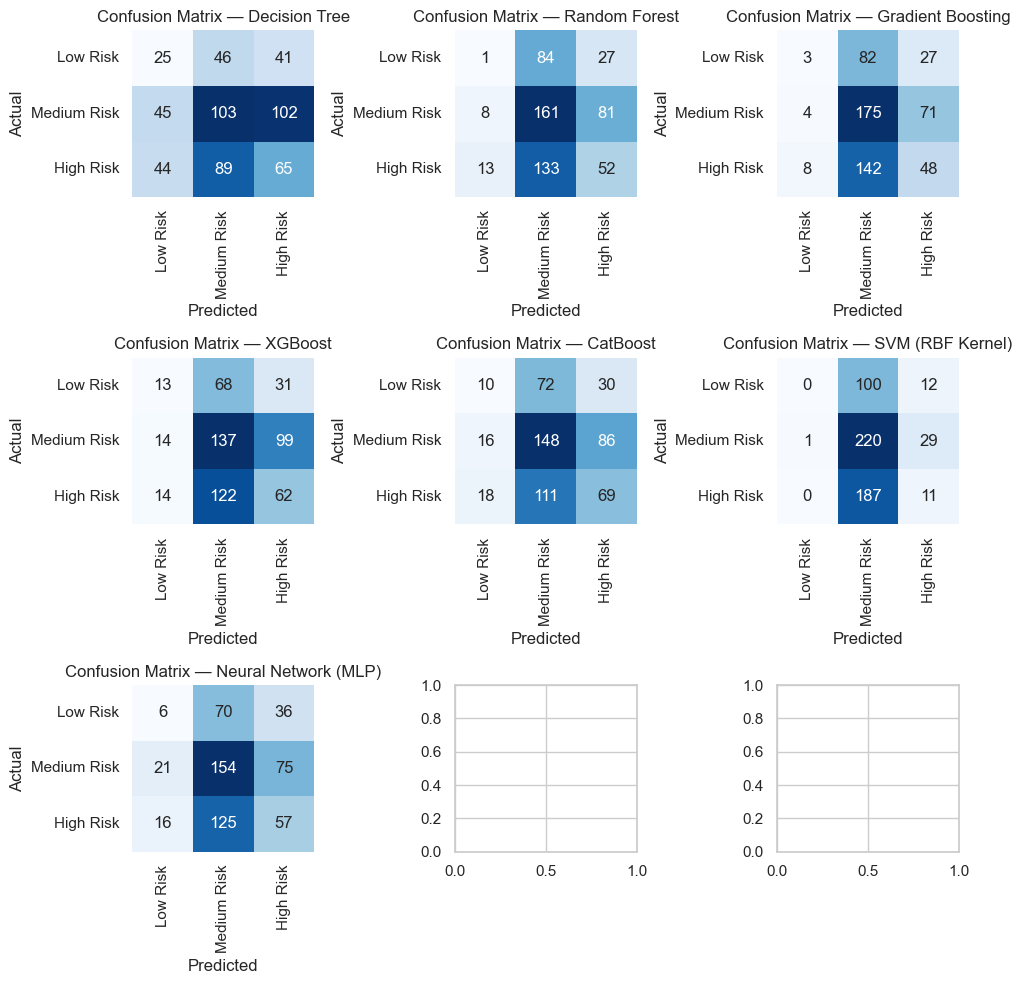

In [76]:
plot_confusion_matrix(all_predictions,y_test,labels=["Low Risk", "Medium Risk", "High Risk"])